### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture

In [130]:
raw_df = pd.read_csv('~/ml_course/Модуль 3. Навчання без учителя/dataframes/marketing_campaign.csv', sep=None, engine='python')
print(f"Розмір датасету: {raw_df.shape}")

Розмір датасету: (2240, 29)


In [131]:
raw_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [132]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [133]:
missing_values = raw_df.isnull().sum()
print(missing_values[missing_values > 0])

Income    24
dtype: int64


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [134]:
raw_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [135]:
raw_df.Income.mode()

0    7500.0
Name: Income, dtype: float64

In [136]:
raw_df['Income'] = raw_df['Income'].fillna(raw_df['Income'].median())

Для заповнення пропущених значень було обрано медіану, оскільки вона є стійкою до викидів у даних  - наприклад, аномально високих доходів,

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [137]:
raw_df['Dt_Customer'] = pd.to_datetime(raw_df['Dt_Customer'], dayfirst=True)
newest_customer = raw_df['Dt_Customer'].max()
raw_df['Customer_Days'] = (newest_customer - raw_df['Dt_Customer']).dt.days

In [138]:
raw_df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [139]:
raw_df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [140]:
raw_df['Marital_Status'] = raw_df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')
raw_df['Age'] = 2026 - raw_df['Year_Birth']

In [141]:
print(raw_df['Z_CostContact'].value_counts())
print(raw_df['Z_Revenue'].value_counts())

Z_CostContact
3    2240
Name: count, dtype: int64
Z_Revenue
11    2240
Name: count, dtype: int64


In [142]:
categorical_cols = raw_df.select_dtypes('str').columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(raw_df[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
raw_df[encoded_cols] = encoder.transform(raw_df[categorical_cols])

In [143]:
cols_to_drop = ['Z_CostContact', 'Z_Revenue', 'ID', 'Dt_Customer', 'Year_Birth'] + categorical_cols
raw_df = raw_df.drop(columns=cols_to_drop)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [144]:
X = raw_df.copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print(f"Silhouette score: {score:.4f}")

Silhouette score: 0.5379


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [145]:
mnt_cols = [col for col in X.columns if 'Mnt' in col]
X['Total_Mnt'] = X[mnt_cols].sum(axis=1)
X['Cluster'] = labels

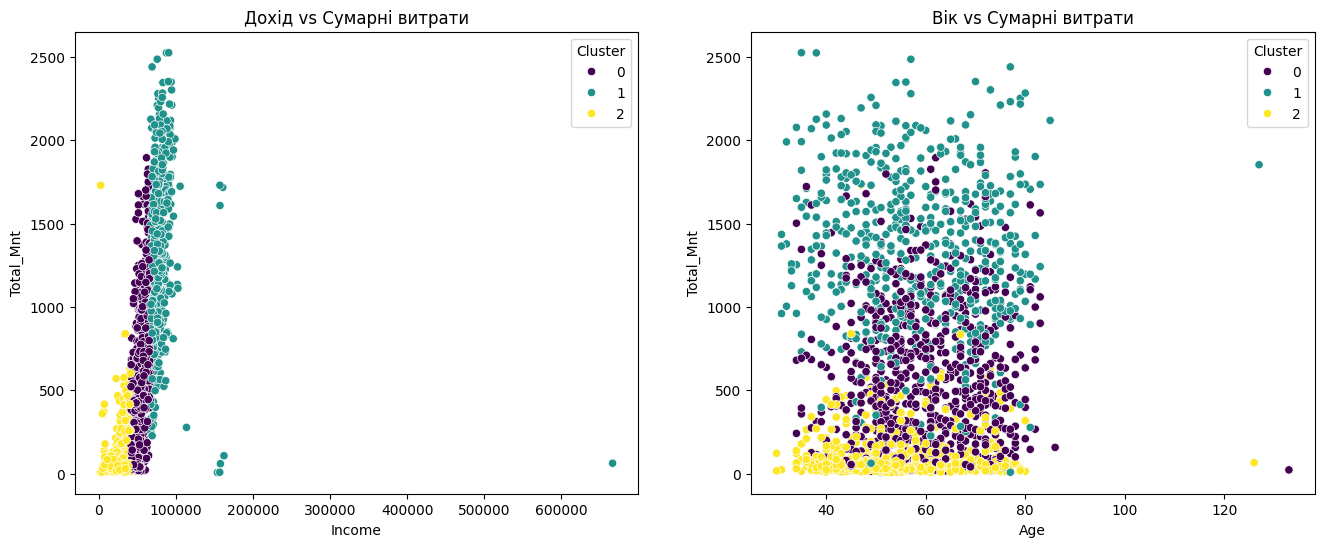

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue='Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('Дохід vs Сумарні витрати')

sns.scatterplot(data=X, x='Age', y='Total_Mnt', hue='Cluster', palette='viridis', ax=axes[1])
axes[1].set_title('Вік vs Сумарні витрати')

plt.show()

Найбільш інформативним виявився графік Дохід vs Сумарні витрати, де видно пряму залежність: чим більший дохід, тим більше клієнт витрачає в магазині. Графік Вік vs Сумарні витрати показує повну відсутність впливу віку на формування кластерів — кольори перемішані рівномірно. Це свідчить про те, що ознаки з великими числовими значеннями домінують над іншими.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [147]:
X_scaled = X.drop(columns=['Cluster', 'Total_Mnt']) 

scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X_scaled)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

new_score = silhouette_score(X_scaled, labels_scaled)
print(f'Silhouette score Scaled: {new_score:.4f}')

Silhouette score Scaled: 0.1077


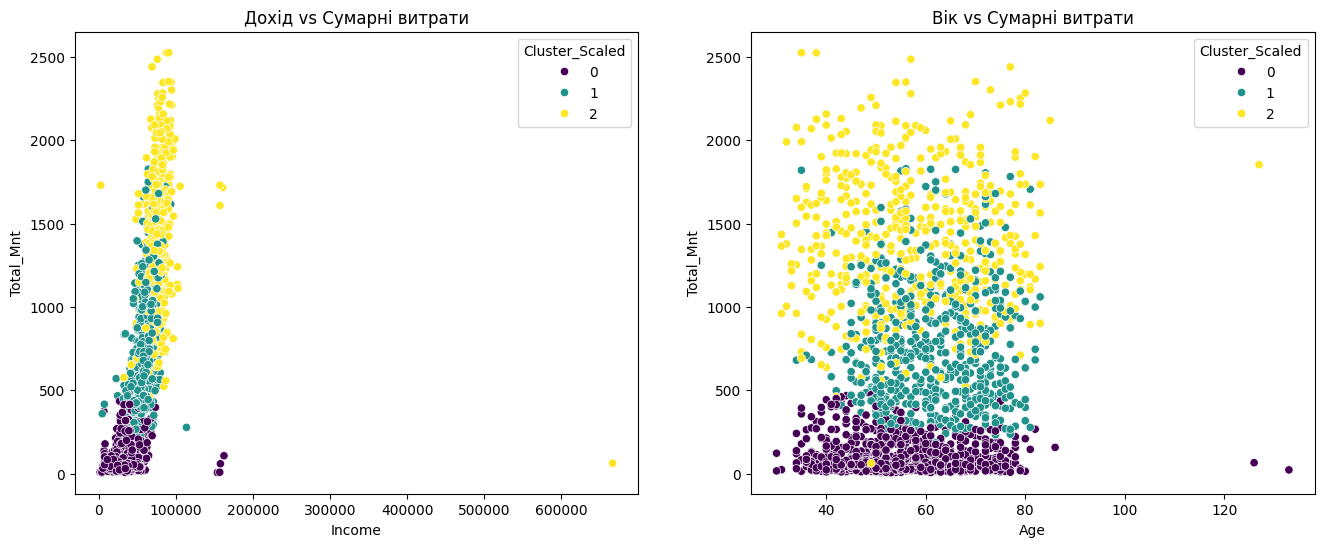

In [148]:
X['Cluster_Scaled'] = labels_scaled

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue='Cluster_Scaled', palette='viridis', ax=axes[0])
axes[0].set_title('Дохід vs Сумарні витрати')

sns.scatterplot(data=X, x='Age', y='Total_Mnt', hue='Cluster_Scaled', palette='viridis', ax=axes[1])
axes[1].set_title('Вік vs Сумарні витрати')

plt.show()

Хоча візуально межі кластерів стали менш чіткими порівняно з експериментом без масштабування, така сегментація є значно якіснішою. Алгоритм перестав залежати виключно від ознаки Income. Без масштабування кластери були лише відображенням рівня багатства низький, середній або високий. З масштабуванням ми бачимо перетин груп за доходами. Це свідчить про те, що тепер модель групує клієнтів за їхньою поведінкою, а не лише за сумою на рахунку. На графіку Вік vs Сумарні витрати помітно кращу групованість точок за кольорами.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [149]:
def one_time_analysis (my_df, column_name):
    Q1 = my_df[column_name].quantile(0.25)
    Q3 = my_df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    upper = (Q3 + 1.5 * IQR)    
    print(f"Ознака: {column_name:15} | Межа викидів: {upper:>10.2f}")
    return upper

In [150]:
cols_to_fix = ['Age', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

for col in cols_to_fix:
    high = one_time_analysis(X, col)
    X[col] = X[col].clip(upper=high)

Ознака: Age             | Межа викидів:      94.00
Ознака: Income          | Межа викидів:  117416.25
Ознака: MntWines        | Межа викидів:    1225.00
Ознака: MntFruits       | Межа викидів:      81.00
Ознака: MntMeatProducts | Межа викидів:     556.00
Ознака: MntFishProducts | Межа викидів:     120.50
Ознака: MntSweetProducts | Межа викидів:      81.00
Ознака: MntGoldProds    | Межа викидів:     126.50


Для обробки викидів використано метод обрізання за верхньою межею 1,5 * IQR. Це дозволило усунути спотворення масштабу, спричинене аномальними значеннями, без втрати кількості спостережень у датасеті

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [151]:
X_final = X.drop(columns=['Cluster', 'Cluster_Scaled', 'Total_Mnt'])
scaler = StandardScaler().set_output(transform="pandas")
X_scaled_final = scaler.fit_transform(X_final)

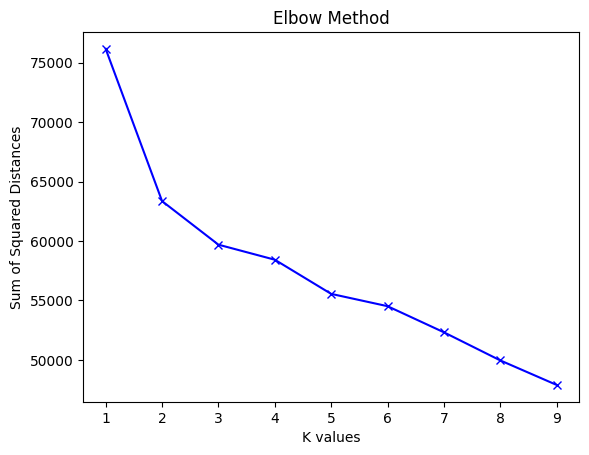

In [152]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_scaled_final)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [153]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
final_labels = final_kmeans.fit_predict(X_scaled_final)

final_score = silhouette_score(X_scaled_final, final_labels)
print(f'Final Silhouette score  Scaled (K={optimal_k}): {final_score:.4f}')

X['Final_Cluster_Scaled'] = final_labels

Final Silhouette score  Scaled (K=3): 0.1177


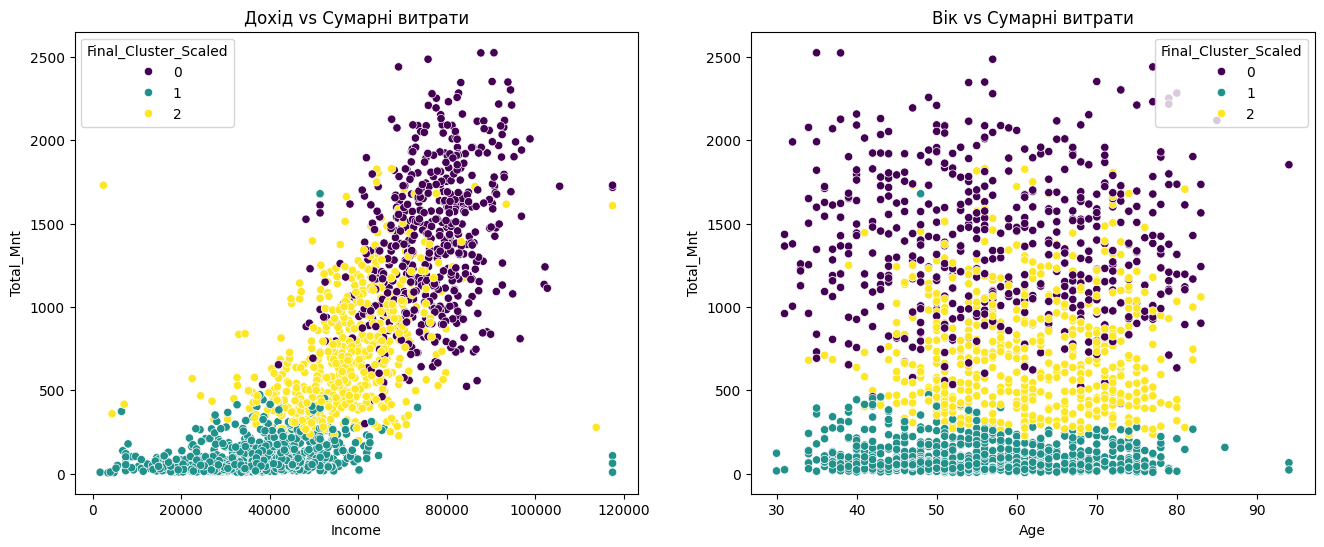

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue='Final_Cluster_Scaled', palette='viridis', ax=axes[0])
axes[0].set_title('Дохід vs Сумарні витрати')

sns.scatterplot(data=X, x='Age', y='Total_Mnt', hue='Final_Cluster_Scaled', palette='viridis', ax=axes[1])
axes[1].set_title('Вік vs Сумарні витрати')

plt.show()

In [155]:
X_final_2 = X.drop(columns=['Cluster', 'Cluster_Scaled', 'Total_Mnt', 'Final_Cluster_Scaled'])

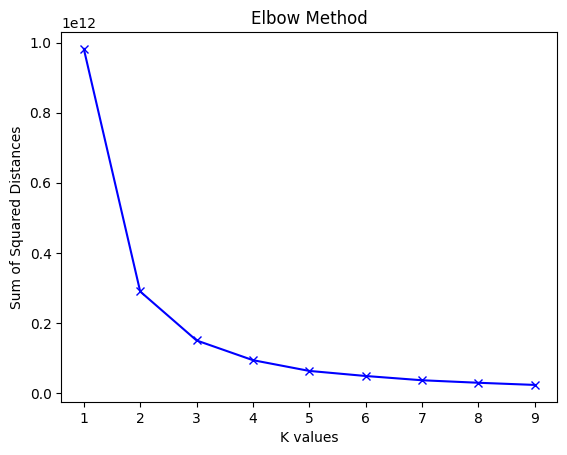

In [156]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_final_2)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [157]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, n_init='auto', random_state=42)
final_labels = final_kmeans.fit_predict(X_final_2)

final_score = silhouette_score(X_final_2, final_labels)
print(f'Final Silhouette score (K={optimal_k}): {final_score:.4f}')

X['Final_Cluster_2'] = final_labels

Final Silhouette score (K=3): 0.5479


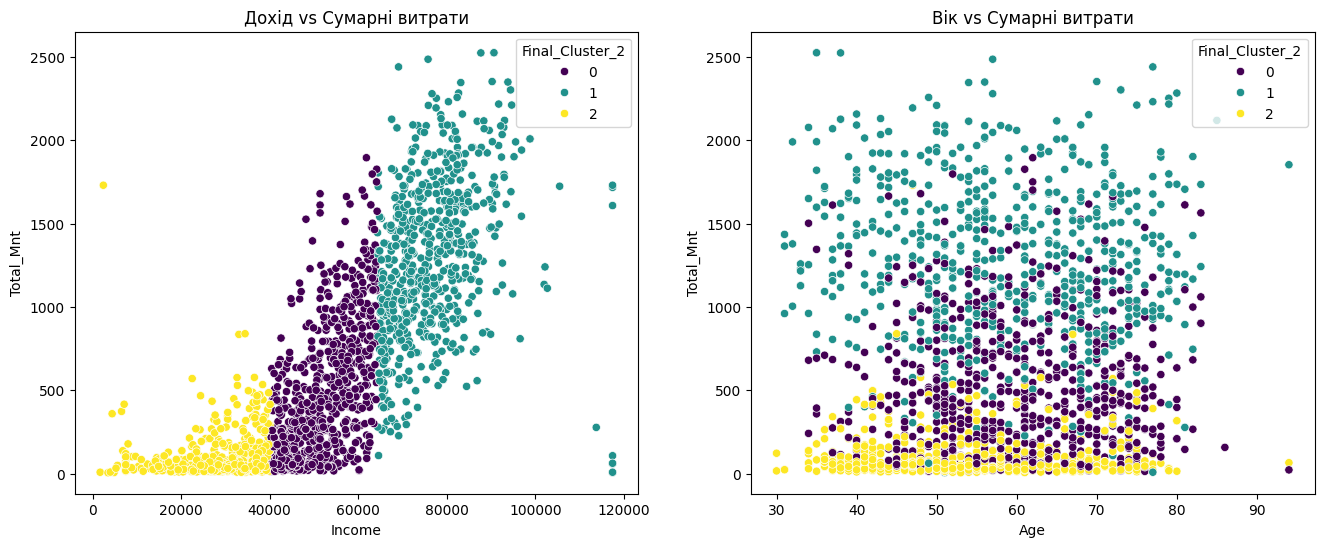

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue='Final_Cluster_2', palette='viridis', ax=axes[0])
axes[0].set_title('Дохід vs Сумарні витрати')

sns.scatterplot(data=X, x='Age', y='Total_Mnt', hue='Final_Cluster_2', palette='viridis', ax=axes[1])
axes[1].set_title('Вік vs Сумарні витрати')

plt.show()

Незважаючи на високі показники силуету на сирих даних, найкращим вибором є робота з масштабованими даними. Це дозволяє уникнути домінування великого доходу.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [159]:
X_single_linkage = X.drop(columns=['Cluster', 'Cluster_Scaled', 'Total_Mnt', 'Final_Cluster_Scaled', 'Final_Cluster_2'])

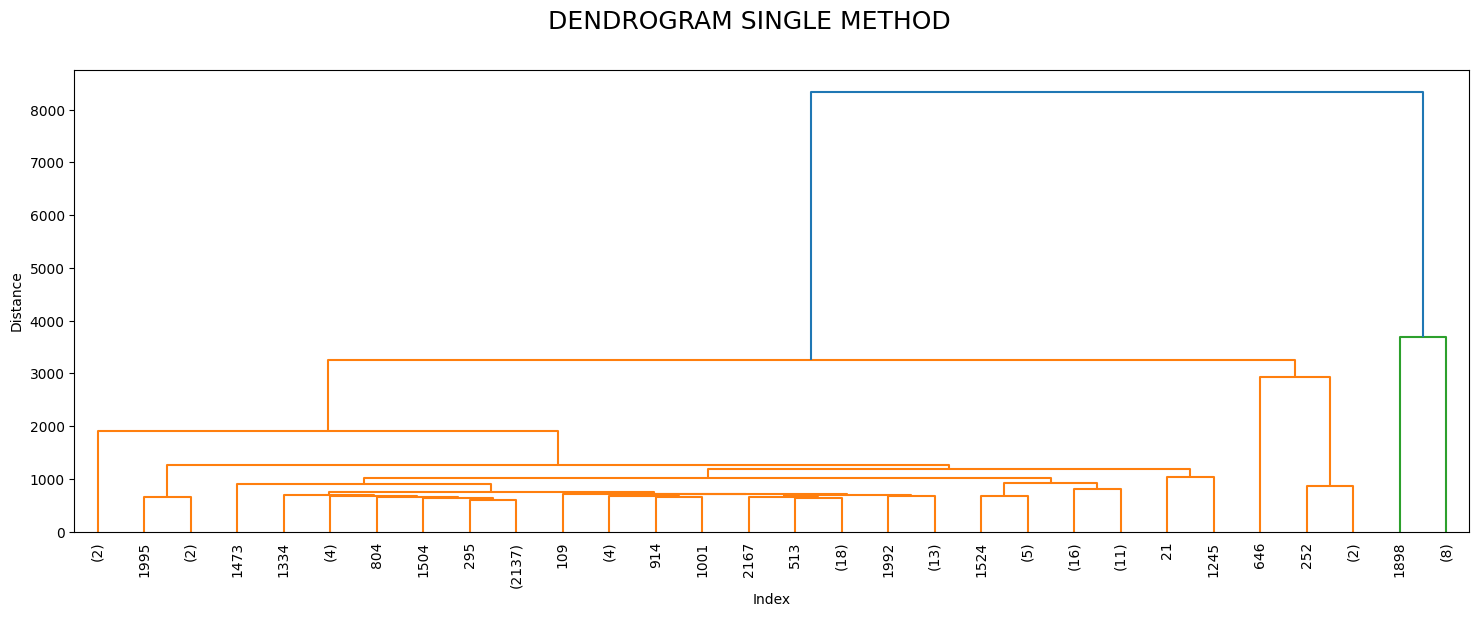

In [160]:
dist_sin = linkage(X_single_linkage, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

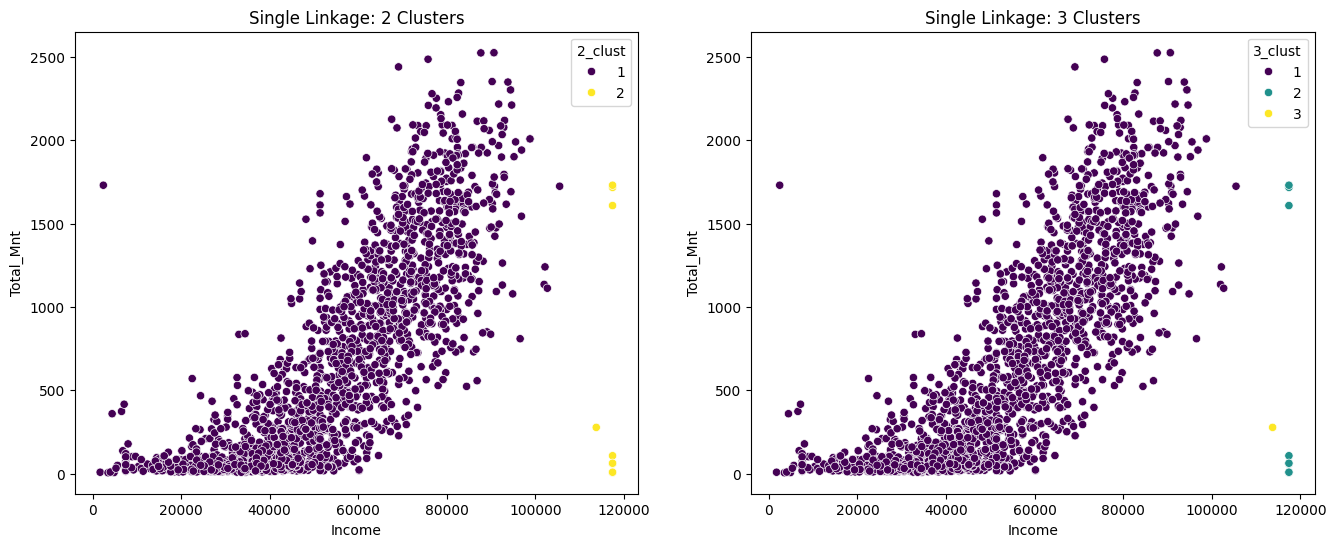

Silhouette Score (2 clusters): 0.5861
Silhouette Score (3 clusters): 0.5586


In [161]:
X_single_linkage['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X_single_linkage['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue=X_single_linkage['2_clust'], palette='viridis')
plt.title('Single Linkage: 2 Clusters')

plt.subplot(1, 2, 2)
sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue=X_single_linkage['3_clust'], palette='viridis')
plt.title('Single Linkage: 3 Clusters')
plt.show()

score_2 = silhouette_score(X_single_linkage.drop(columns=['2_clust', '3_clust']), X_single_linkage['2_clust'])
score_3 = silhouette_score(X_single_linkage.drop(columns=['2_clust', '3_clust']), X_single_linkage['3_clust'])

print(f"Silhouette Score (2 clusters): {score_2:.4f}")
print(f"Silhouette Score (3 clusters): {score_3:.4f}")

Візуалізація чітко показує неспроможність методу Single Linkage для даного датасету. Алгоритм не зміг сегментувати основну масу клієнтів, натомість він просто виділив поодинокі викиди в окремі кластери. Це підтверджує, що ієрархічна кластеризація з таким типом зв'язку на невідмасштабованих даних не підходить для вирішення бізнес-задач сегментації. Порівняно з цим, метод KMeans дав набагато більш збалансовані та придатні для аналізу результати.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [162]:
gmm = GaussianMixture(n_components=3, random_state=42)

gmm_labels = gmm.fit_predict(X_scaled_final)

gmm_score = silhouette_score(X_scaled_final, gmm_labels)
print(f'GMM Silhouette score: {gmm_score:.4f}')

X['GMM_Cluster'] = gmm_labels

GMM Silhouette score: 0.0959


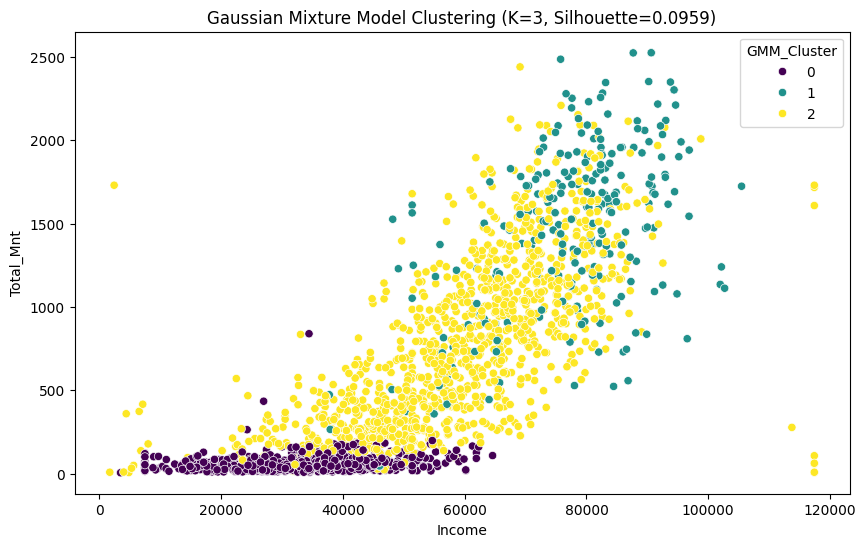

In [163]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='Income', y='Total_Mnt', hue='GMM_Cluster', palette='viridis')
plt.title(f'Gaussian Mixture Model Clustering (K=3, Silhouette={gmm_score:.4f})')
plt.show()

Використано модель Гаусових сумішей (GMM), яка використовує імовірнісний підхід до розділення даних. Silhouette Score вийшов трішки менше ніж KMeans. Ця кластеризація була б дуже корисною для реального бізнесу. Завдяки імовірнісній природі GMM, ми можемо виділити клієнтів, які знаходяться на межі між сегментами. Наприклад, ми можемо ідентифікувати тих, хто зараз у сегменті середніх, але за своєю поведінкою вже наближається до високих, і стимулювати їх спеціальними пропозиціями.